# Cats Vs Dogs

La seccion consiste en entrenar un modelo para clasificar imagenes de perros e imagenes de gatos con una red convolucional. Sin contar con una cantidad particularmente grande de datos de entrenamiento.

# Descargar datos

Los datos provienen de la competencia de **Kaggle**  *dogs-vs-cats*. Se pueden descargar con la api de kaggle. 

Antes de solicitar los datos asegurate de tener instalado el paquete `kaggle` y de tener creado el archivo *C:\Users\<tu_usuario>\.kaggle\kaggle.json* con tu Key personal.

In [4]:
!kaggle competitions download -c dogs-vs-cats

 88%|███████████████████████████████████     | 713M/812M [00:00<00:00, 1.47GB/s]
100%|████████████████████████████████████████| 812M/812M [00:00<00:00, 1.48GB/s]


Los datos se pueden extraer con `!unzip`.

# Dividir datos

No vamos a usar todos los ejemplos solo 2000 train, 1000 val, 1000 test. (de 25000 muestras).

Crear carpetas y dividir dataset:

In [ ]:
import os, shutil

# Path de datos originales
original_dataset_dir = os.path.expanduser('~/libros/dlwp/datasets/kaggle_original_data/dogs-vs-cats/train')
# Path donde guardar la rebanada de datos
base_dir = os.path.expanduser('~/libros/dlwp/datasets/kaggle_original_data/cats_and_dogs_small')
os.mkdir(base_dir)

# Directorios particulares a cada conjunto
train_dir = os.path.join(base_dir, 'train')
os.mkdir(train_dir)
validation_dir = os.path.join(base_dir, 'validation')
os.mkdir(validation_dir)
test_dir = os.path.join(base_dir, 'test')
os.mkdir(test_dir)

# Otra division para separar imagenes de gato y perro
train_cats_dir = os.path.join(train_dir, 'cats')
os.mkdir(train_cats_dir)
train_dogs_dir = os.path.join(train_dir, 'dogs')
os.mkdir(train_dogs_dir)
validation_cats_dir = os.path.join(validation_dir, 'cats')
os.mkdir(validation_cats_dir)
validation_dogs_dir = os.path.join(validation_dir, 'dogs')
os.mkdir(validation_dogs_dir)
test_cats_dir = os.path.join(test_dir, 'cats')
os.mkdir(test_cats_dir)
test_dogs_dir = os.path.join(test_dir, 'dogs')
os.mkdir(test_dogs_dir)

# Copiar 1000 primeras imagenes de gatos para train
fnames = ['cat.{}.jpg'.format(i) for i in range(1000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(train_cats_dir, fname)
    shutil.copyfile(src, dst)

# Copiar 1000 primeras imagenes de perros para train
fnames = ['dog.{}.jpg'.format(i) for i in range(1000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(train_dogs_dir, fname)
    shutil.copyfile(src, dst)

# Copiar 500 imagenes de gatos para val
fnames = ['cat.{}.jpg'.format(i) for i in range(1000, 1500)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(validation_cats_dir, fname)
    shutil.copyfile(src, dst)

# Copiar 500 imagenes de perros para val
fnames = ['dog.{}.jpg'.format(i) for i in range(1000, 1500)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(validation_dogs_dir, fname)
    shutil.copyfile(src, dst)

# Copiar 500 imagenes de gatos para test
fnames = ['cat.{}.jpg'.format(i) for i in range(1500, 2000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(test_cats_dir, fname)
    shutil.copyfile(src, dst)

# Copiar 500 imagenes de perros para test
fnames = ['dog.{}.jpg'.format(i) for i in range(1500, 2000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(test_dogs_dir, fname)
    shutil.copyfile(src, dst)

# Checqueo
print('total training cat images:', len(os.listdir(train_cats_dir)))
print('total training dog images:', len(os.listdir(train_dogs_dir)))
print('total validation cat images:', len(os.listdir(validation_cats_dir)))
print('total validation dog images:', len(os.listdir(validation_dogs_dir)))
print('total test cat images:', len(os.listdir(test_cats_dir)))
print('total test dog images:', len(os.listdir(test_dogs_dir)))

total training cat images: 1000
total training dog images: 1000
total validation cat images: 500
total validation dog images: 500
total test cat images: 500
total test dog images: 500


# Modelo

Se van a alternar varias capas *convolucionales* con capas de *pooling*.

In [1]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPool2D((2,2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()


2025-07-25 13:35:33.099852: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753461333.117680  557821 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753461333.123088  557821 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753461333.137160  557821 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753461333.137181  557821 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753461333.137183  557821 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
from tensorflow.keras import optimizers

model.compile(loss='binary_crossentropy', 
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['acc'])

# Alimentador

Generador de datos de archivos (aprovechando facilidades de tensorflow):

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

base_dir = os.path.expanduser('~/libros/dlwp/datasets/kaggle_original_data/cats_and_dogs_small')
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary' # Clasificacion binaria -> labels binarios
)

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary' # Clasificacion binaria -> labels binarios
)

Found 2000 images belonging to 2 classes.


Found 1000 images belonging to 2 classes.
data batch shape: (20, 150, 150, 3)
labels batch shape: (20,)


Comprobar lotes generados:

In [10]:
for data_batch, labels_batch in train_generator:
    print('data batch shape:', data_batch.shape)
    print('labels batch shape:', labels_batch.shape)
    break

data batch shape: (20, 150, 150, 3)
labels batch shape: (20,)


# Entrenar
Se realiza el entrenamiento del modelo:

In [12]:
history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs = 30,
    validation_data=validation_generator,
    validation_steps=50)

Epoch 1/30


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1753465884.143969  557906 service.cc:152] XLA service 0x7f54c800a7b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753465884.143988  557906 service.cc:160]   StreamExecutor device (0): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2025-07-25 14:51:24.178984: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1753465884.388744  557906 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-07-25 14:51:24.688359: I external/l

  7/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.4372 - loss: 0.7012

I0000 00:00:1753465886.570840  557906 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.4969 - loss: 0.6975

2025-07-25 14:51:29.255381: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.12 = (f32[20,32,148,148]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,3,150,150]{3,2,1,0} %bitcast.436, f32[32,3,3,3]{3,2,1,0} %bitcast.443, f32[32]{0} %bitcast.445), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/conv2d_1/convolution" source_file="/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-25 14:51:29.284111: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially 

100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - acc: 0.4971 - loss: 0.6974 - val_acc: 0.5000 - val_loss: 0.6880
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - acc: 0.5537 - loss: 0.6851 - val_acc: 0.6070 - val_loss: 0.6720
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - acc: 0.6253 - loss: 0.6615 - val_acc: 0.6030 - val_loss: 0.6477
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - acc: 0.6529 - loss: 0.6109 - val_acc: 0.6590 - val_loss: 0.6183
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - acc: 0.7034 - loss: 0.5846 - val_acc: 0.6710 - val_loss: 0.6005
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - acc: 0.7133 - loss: 0.5599 - val_acc: 0.6690 - val_loss: 0.5948
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - acc: 0.7309 - loss: 0.5294 - val_acc: 0.6720 - val_loss: 0.5813
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - acc: 0.7582 - loss: 0.4848 - val_acc: 0.6930 - val_loss: 0.5719
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - acc:

Es buena practica guardar el modelo despues de entrenar:

In [14]:
model.save('./models/cats_and_dogs_small_1.h5')

Analisis grafico:

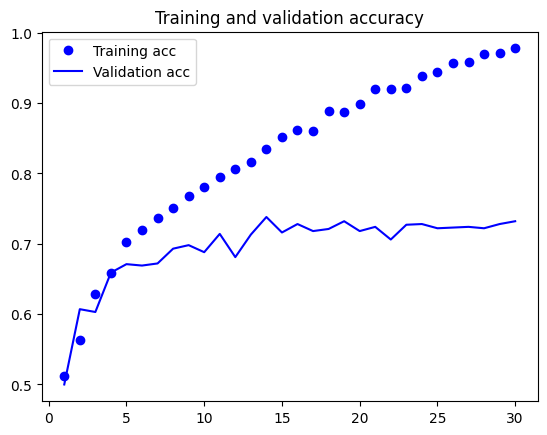

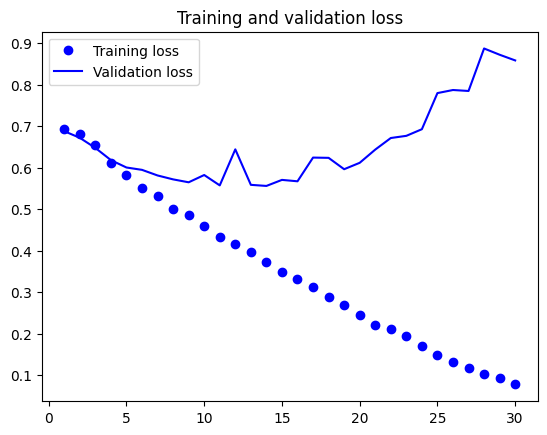

In [15]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

Hay un claro *overfitting* a partir de la epoca 10.

En Validación Acc $= 0.73$ en el mejor momento.

# Data Augmentation

Ahora se va a probar la misma configuración pero empleando *data augmentation* para tratar el *overfitting*.

*Paths* importantes:

In [ ]:
base_dir = os.path.expanduser('~/libros/dlwp/datasets/kaggle_original_data/cats_and_dogs_small')
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')
test_cats_dir = os.path.join(test_dir, 'cats')
test_dogs_dir = os.path.join(test_dir, 'dogs')

Muestra de *data augmentation*:

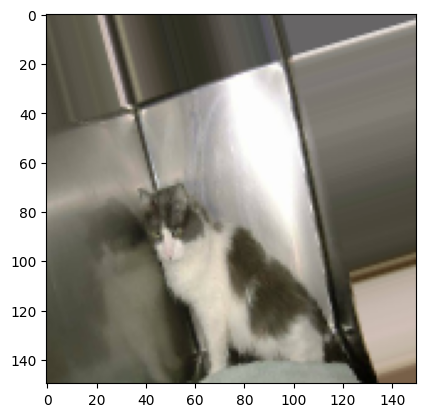

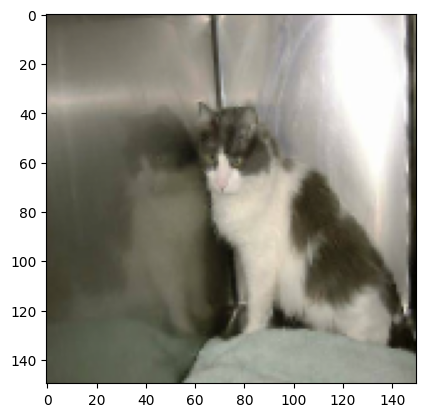

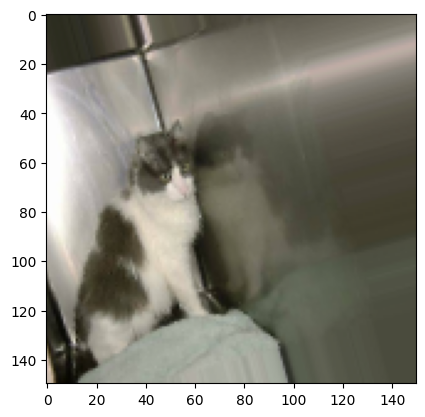

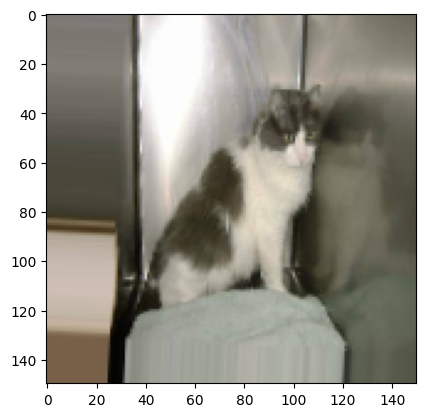

In [ ]:
from keras.preprocessing import image

datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

fnames = [os.path.join(train_cats_dir, fname) for fname in os.listdir(train_cats_dir)]

img_path = fnames[3]

img = image.load_img(img_path, target_size=(150,150))

x = image.img_to_array(img)
x = x.reshape((1,) + x.shape) # Una dimension delante para representar la cantidad de ejemplos: (1,150,150,3)

i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if(i % 4 == 0):
        break

plt.show()


Solo se ofrecio 1 imgan, aun asi se generaron 4 variaciones.

Modelo y entrenamineto:

In [22]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['acc'])

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255) # NO aumentar los datos de validación.

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary')

history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=100,
    validation_data=validation_generator,
    validation_steps=50)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


2025-07-25 17:06:40.621263: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.12 = (f32[32,32,148,148]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,150,150]{3,2,1,0} %bitcast.2413, f32[32,3,3,3]{3,2,1,0} %bitcast.2420, f32[32]{0} %bitcast.3024), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_3_1/conv2d_12_1/convolution" source_file="/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-25 17:06:40.667251: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted pote

  8/100 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - acc: 0.5368 - loss: 0.6960

2025-07-25 17:06:43.910273: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.12 = (f32[16,32,148,148]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,150,150]{3,2,1,0} %bitcast.2413, f32[32,3,3,3]{3,2,1,0} %bitcast.2420, f32[32]{0} %bitcast.3024), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_3_1/conv2d_12_1/convolution" source_file="/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-25 17:06:43.924142: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted pote

 63/100 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - acc: 0.5274 - loss: 0.6944

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2025-07-25 17:06:53.941751: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.12 = (f32[32,32,148,148]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,150,150]{3,2,1,0} %bitcast.436, f32[32,3,3,3]{3,2,1,0} %bitcast.443, f32[32]{0} %bitcast.445), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_3_1/conv2d_12_1/convolution" source_file="/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/tensorflow/python/framework/op

100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - acc: 0.5254 - loss: 0.6939 - val_acc: 0.5280 - val_loss: 0.6854
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - acc: 0.5414 - loss: 0.6845 - val_acc: 0.5650 - val_loss: 0.6701
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - acc: 0.5572 - loss: 0.6787 - val_acc: 0.5580 - val_loss: 0.6698
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - acc: 0.5866 - loss: 0.6673 - val_acc: 0.6010 - val_loss: 0.6517
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - acc: 0.6128 - loss: 0.6568 - val_acc: 0.6210 - val_loss: 0.6456
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - acc: 0.5961 - loss: 0.6569 - val_acc: 0.5570 - val_loss: 0.6685
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - acc: 0.6168 - loss: 0.6490 - val_acc: 0.6110 - val_loss: 0.6367
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - acc: 0.6234 - loss: 0.6438 - val_acc: 0.5970 - val_loss: 0.6356
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━

In [24]:
model.save('./models/cats_and_dogs_small_2.h5')

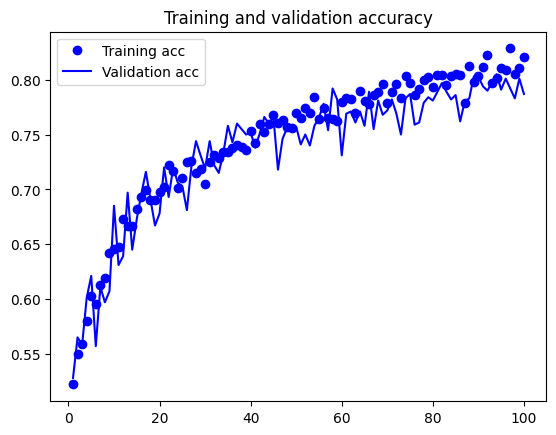

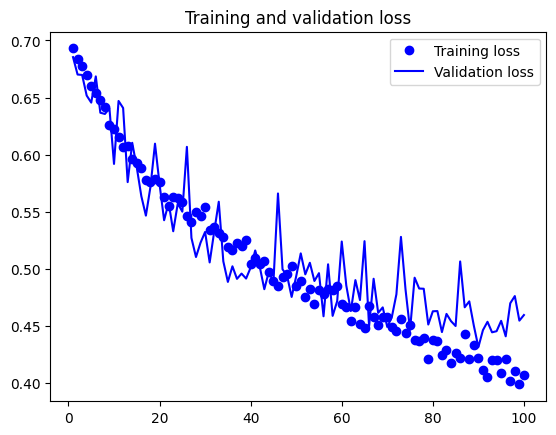

In [25]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

Como se puede ver disminuyo el *overfitting*. El mejor error fue de $0.40$ y el mejor *Acc* fue de $0.80$.

Recien en la iteración 70 se aprecia cierto grado de *overfitting*.

# Data Augmentation y Dropout

Para un mejor resultado se aplica tanto *data augmentation* como *dropout*.

In [1]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

model.compile(loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['acc'])

2025-07-27 15:39:14.989881: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753641555.007940  580162 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753641555.013550  580162 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753641555.027685  580162 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753641555.027704  580162 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753641555.027706  580162 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

base_dir = os.path.expanduser('~/libros/dlwp/datasets/kaggle_original_data/cats_and_dogs_small')
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255) # NO aumentar los datos de validación.

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary')

history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=100,
    validation_data=validation_generator,
    validation_steps=50)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1753641563.522878  580193 service.cc:152] XLA service 0x7f534000aa50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753641563.522897  580193 service.cc:160]   StreamExecutor device (0): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2025-07-27 15:39:23.558974: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1753641563.784602  580193 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-07-27 15:39:24.218370: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.12 = (f32[32,32,148,148]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,150,150]{3,2,1,0} %bitcast.4759, f32[32,3,3,3]{3,2,1,0} %bitcast.4766, f32[32]{0} %bitcast.5390), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBia

  3/100 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - acc: 0.5278 - loss: 0.6951

...

 44/100 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - acc: 0.5183 - loss: 0.6927

2025-07-27 15:39:33.432741: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.12 = (f32[16,32,148,148]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,150,150]{3,2,1,0} %bitcast.4759, f32[32,3,3,3]{3,2,1,0} %bitcast.4766, f32[32]{0} %bitcast.5390), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/conv2d_1/convolution" source_file="/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-27 15:39:33.446525: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potential

 63/100 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - acc: 0.5162 - loss: 0.6929

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-07-27 15:39:38.297203: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.12 = (f32[32,32,148,148]{3,2,1,0}, u8[0]{0}) custom

100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 139ms/step - acc: 0.5132 - loss: 0.6932 - val_acc: 0.5740 - val_loss: 0.6893
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - acc: 0.5388 - loss: 0.6888 - val_acc: 0.5620 - val_loss: 0.6825
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - acc: 0.5420 - loss: 0.6843 - val_acc: 0.5600 - val_loss: 0.6800
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - acc: 0.5683 - loss: 0.6757 - val_acc: 0.5870 - val_loss: 0.6674
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - acc: 0.5851 - loss: 0.6723 - val_acc: 0.5970 - val_loss: 0.6618
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - acc: 0.5866 - loss: 0.6675 - val_acc: 0.5990 - val_loss: 0.6559
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - acc: 0.5901 - loss: 0.6627 - val_acc: 0.6090 - val_loss: 0.6472
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - acc: 0.6024 - loss: 0.6555 - val_acc: 0.6210 - val_loss: 0.6474
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━

In [3]:
model.save('./models/cats_and_dogs_small_3.keras')

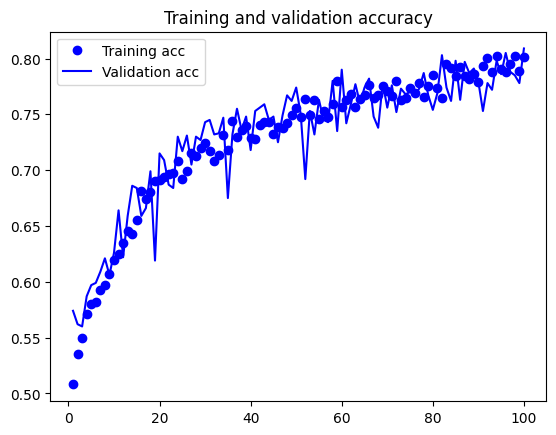

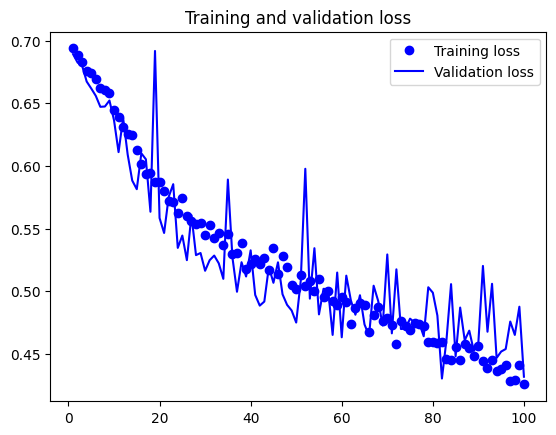

: 

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

El *overfitting* es aun menor ya que no se aprecia un estancamiento claro en ninguna epoca en *loss*, aunque si un indicio en *acc*. No obstante el rendimiento final fue peor: el mejor error fue de $0.45$ y el mejor *acc* fue de $0.80$.

En este punto no parece que el *overfitting* valla a ser un problema, hay que concentrar los esfuerzos enmejorar el *acc*. Ya sea con cambios de arquitectura o con una mejor estrategia de obtencion de datos. Tambien se podria implementar K-Fods Validation para tener mas confianza en las medidas obtenidas.